In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import EFC_learningfMRI.globals as gl
import matplotlib.ticker as mticker
import PcmPy as pcm
import pandas as pd
import seaborn as sb
from EFC_learningfMRI.vis import plot_im_sess, custom_legend
from EFC_learningfMRI.util import get_trained_and_untrained

In [12]:
glm = 3
H = 'L'
atlas = 'ROI'
rois = gl.rois[atlas]
roi = 'M1'
G = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'G_obs.trained-untrained.glm{glm}.{H}.{roi}.npy'))
G.shape

(12, 6, 6)

In [13]:
df_tr_untr = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dist.trained-untrained.glm{glm}.{H}.tsv'), sep='\t',)
df_ch_sess = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dist.chord-session.glm{glm}.{H}.tsv'), sep='\t',)

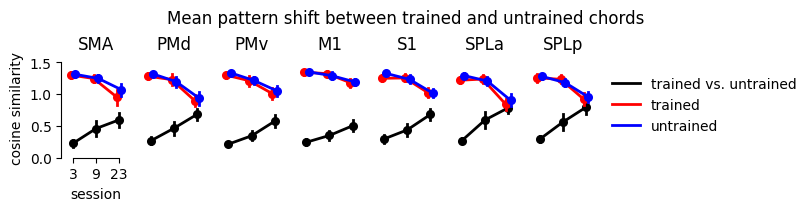

In [16]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)
plot_im_sess(fig, axs, df_tr_untr, rois, x='session', y='angle', dodge=None, color='k')
plot_im_sess(fig, axs, df_ch_sess, rois, x='session', y='angle', hue='chord', hue_order=['trained', 'untrained'], palette=['red', 'blue'])
axs[0].set_ylim(0, np.deg2rad(90))
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('angle (rad)')
axs[0].set_xlabel('session')
fig.suptitle('Mean pattern shift between trained and untrained chords')

axs[-1].get_legend().remove()
custom_legend(fig, labels=['trained vs. untrained', 'trained', 'untrained'], colors=['k', 'r', 'b'])

#fig.savefig(os.path.join(figDir, f'mean_shift.{atlas}.glm{glm}.pdf'))
plt.show()

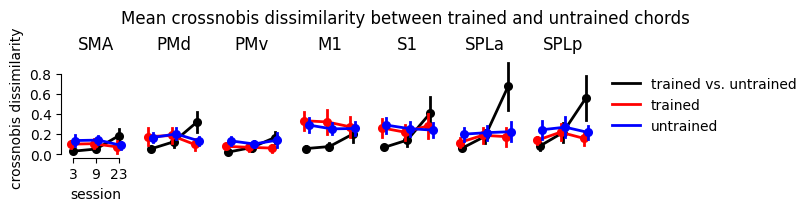

In [15]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)
plot_im_sess(fig, axs, df_tr_untr, rois, x='session', y='dist', dodge=None, color='k')
plot_im_sess(fig, axs, df_ch_sess, rois, x='session', y='dist', hue='chord', hue_order=['trained', 'untrained'], palette=['red', 'blue'])
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('crossnobis dissimilarity')
axs[0].set_xlabel('session')
fig.suptitle('Mean crossnobis dissimilarity between trained and untrained chords')

axs[-1].get_legend().remove()
custom_legend(fig, labels=['trained vs. untrained', 'trained', 'untrained'], colors=['k', 'r', 'b'])

#fig.savefig(os.path.join(figDir, f'mean_shift.{atlas}.glm{glm}.pdf'))
plt.show()